![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

# Layout detection on PDFs with RT-DETR (jsl-layout-heron)

`ImageObjectDetectorRtDetr` runs RT-DETR / RT-DETRv2 ONNX models inside Spark OCR, which detects 17 layout classes:

caption, footnote, formula, list_item, page_footer, page_header, picture, section_header, table, text, title,
document_index, code, checkbox_selected, checkbox_unselected, form, key_value_region.

Point `pdf_path` to a PDF, a folder of PDFs or a glob to try your own documents.

## Configuration
Need specify path to `spark-ocr-assembly-[version].jar` or `secret`, and the folder with the exported
model (`model.onnx` + `labels.txt`).

In [1]:
import os

secret = ""
license = ""
spark_ocr_jar_path = "../../target/scala-2.12"

# a PDF, a folder or a glob, e.g. "/data/my_pdfs/*.pdf"
pdf_path = "./data/pdfs/f1120.pdf"

# rendering resolution for the PDF pages, the model works at 640x640 internally
resolution = 150
score_threshold = 0.5
# empty keeps every class, e.g. ["table", "form", "checkbox_selected", "checkbox_unselected"]
output_labels = []

## Initialization of spark session

In [2]:
from sparkocr import start

if license:
    os.environ['JSL_OCR_LICENSE'] = license

spark = start(secret=secret, jar_path=spark_ocr_jar_path)
spark

Spark version: 3.5.1
Spark NLP version: 7.0.0
Spark NLP for Healthcare version: 7.0.0
Spark OCR version: 7.0.0



## Import OCR transformers

In [3]:
from pyspark.ml import PipelineModel
import pyspark.sql.functions as f

from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import *

## Read PDFs

In [4]:
pdf_df = spark.read.format("binaryFile").load(pdf_path)
pdf_df.select("path", "length").show(truncate=False)

+--------------------------------------------------------------+-------+
|path                                                          |length |
+--------------------------------------------------------------+-------+
|file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/f1120.pdf|3471478|
+--------------------------------------------------------------+-------+



## Define pipeline

In [5]:
pdf_to_image = PdfToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setResolution(resolution) \
    .setImageType(ImageType.TYPE_3BYTE_BGR)

layout_detector = ImageObjectDetectorRtDetr \
    .pretrained("jsl_layout_heron_opt", "en", "clinical/ocr") \
    .setInputCol("image") \
    .setOutputCol("regions") \
    .setScoreThreshold(score_threshold)

draw_regions = ImageDrawRegions() \
    .setInputCol("image") \
    .setInputRegionsCol("regions") \
    .setOutputCol("image_with_regions") \
    .setFilledRect(False) \
    .setDisplayMetadata(True) \
    .setRectColor(Color.green)

pipeline = PipelineModel(stages=[
    pdf_to_image,
    layout_detector,
    draw_regions
])

jsl_layout_heron_opt download started this may take some time.
Approximate size to download 152.8 MB


In [12]:
layout_detector.getOrDefault("labels")

['caption',
 'footnote',
 'formula',
 'list_item',
 'page_footer',
 'page_header',
 'picture',
 'section_header',
 'table',
 'text',
 'title',
 'document_index',
 'code',
 'checkbox_selected',
 'checkbox_unselected',
 'form',
 'key_value_region']

## Run pipeline and show results


    Image #0:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/f1120.pdf
    Resolution: 150 dpi
    Width: 1274 px
    Height: 1649 px
    Mode: ImageType.TYPE_3BYTE_BGR
    Number of channels: 3


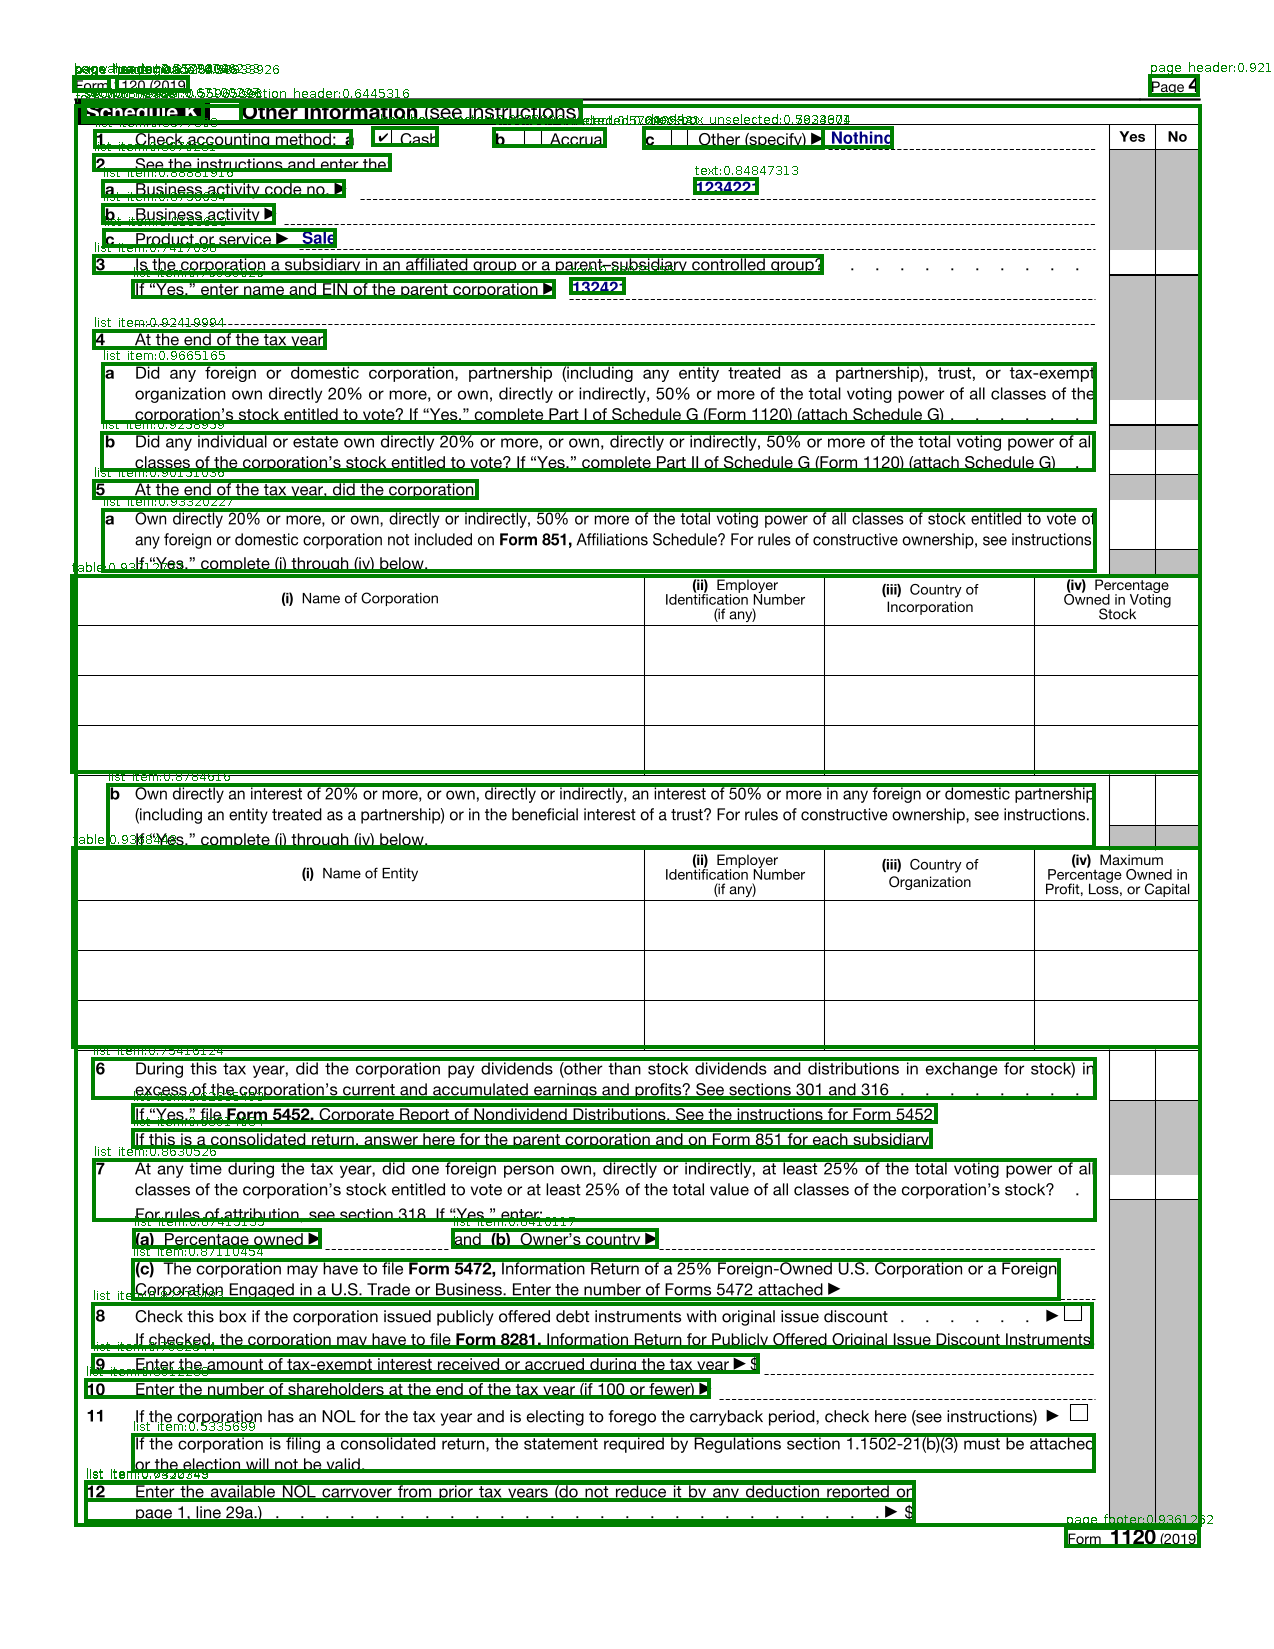


    Image #1:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/f1120.pdf
    Resolution: 150 dpi
    Width: 1274 px
    Height: 1649 px
    Mode: ImageType.TYPE_3BYTE_BGR
    Number of channels: 3


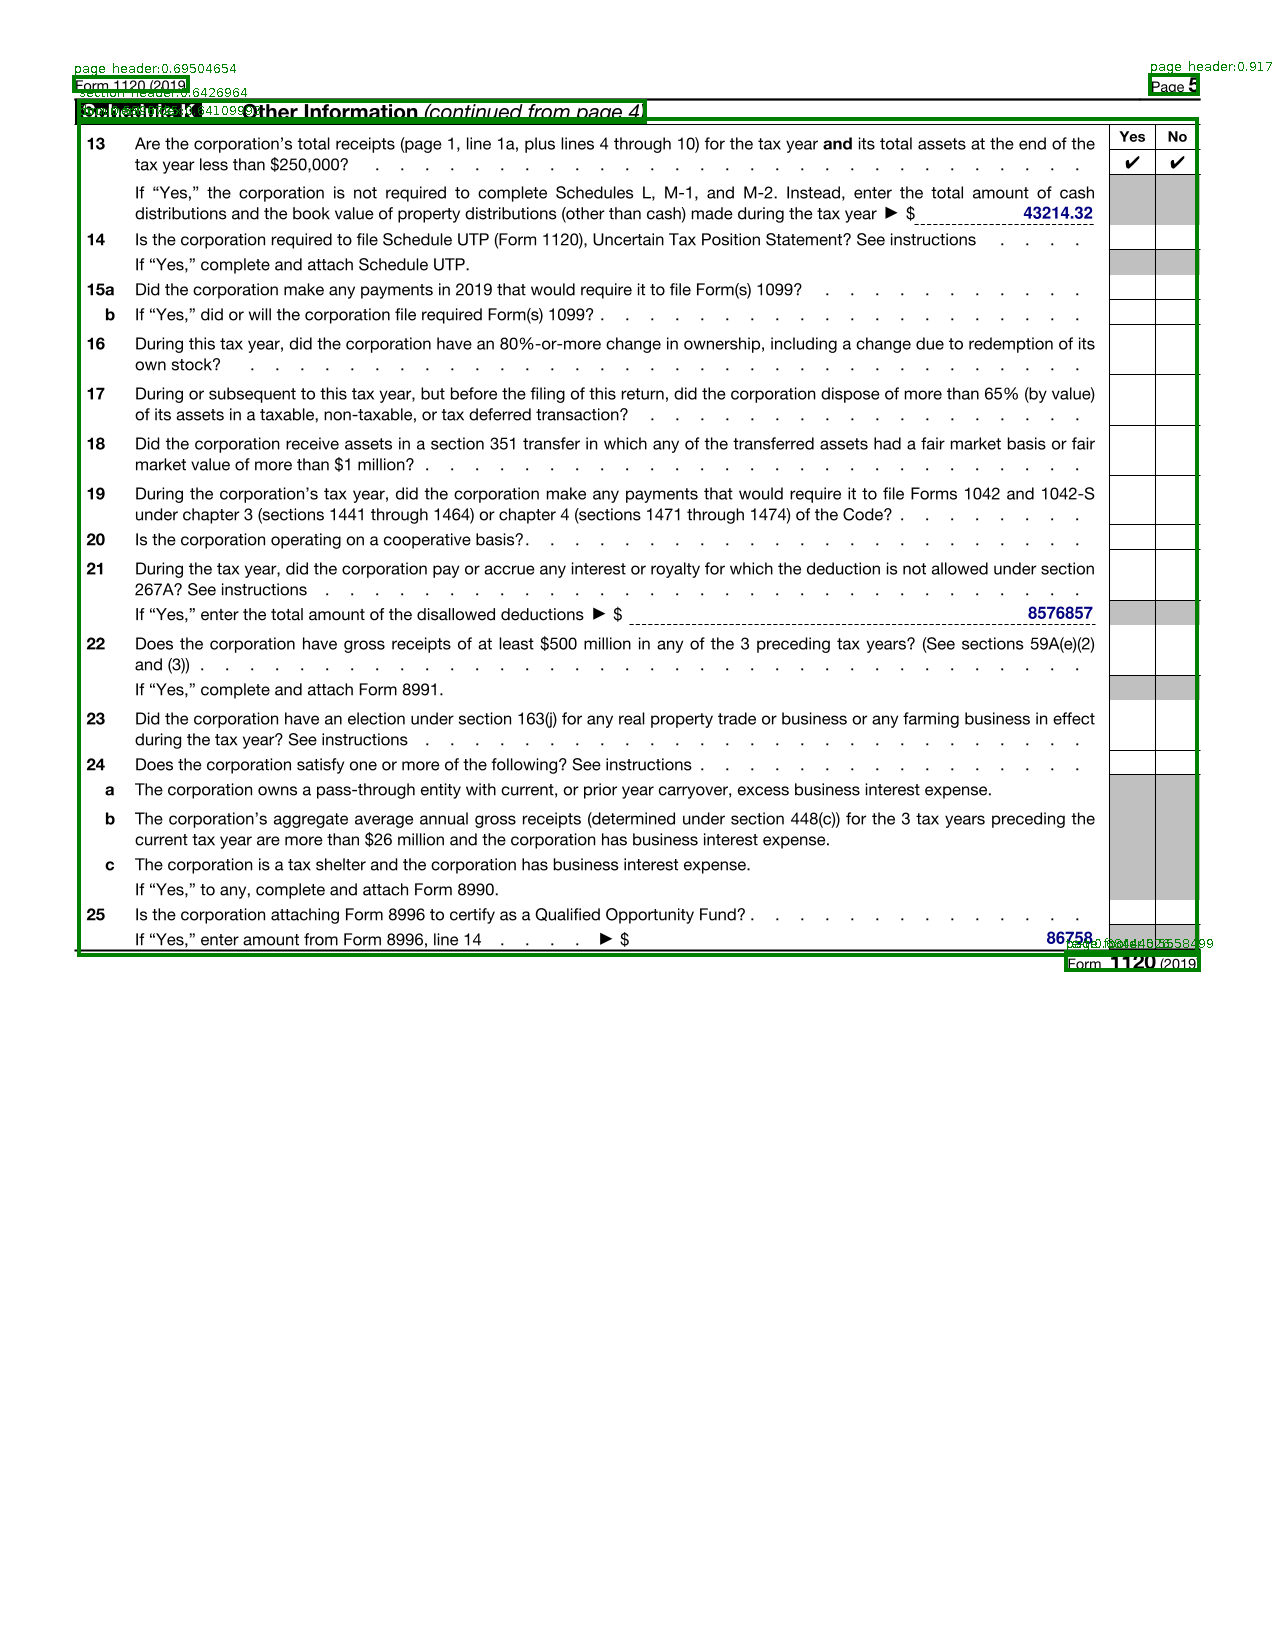


    Image #2:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/f1120.pdf
    Resolution: 150 dpi
    Width: 1274 px
    Height: 1649 px
    Mode: ImageType.TYPE_3BYTE_BGR
    Number of channels: 3


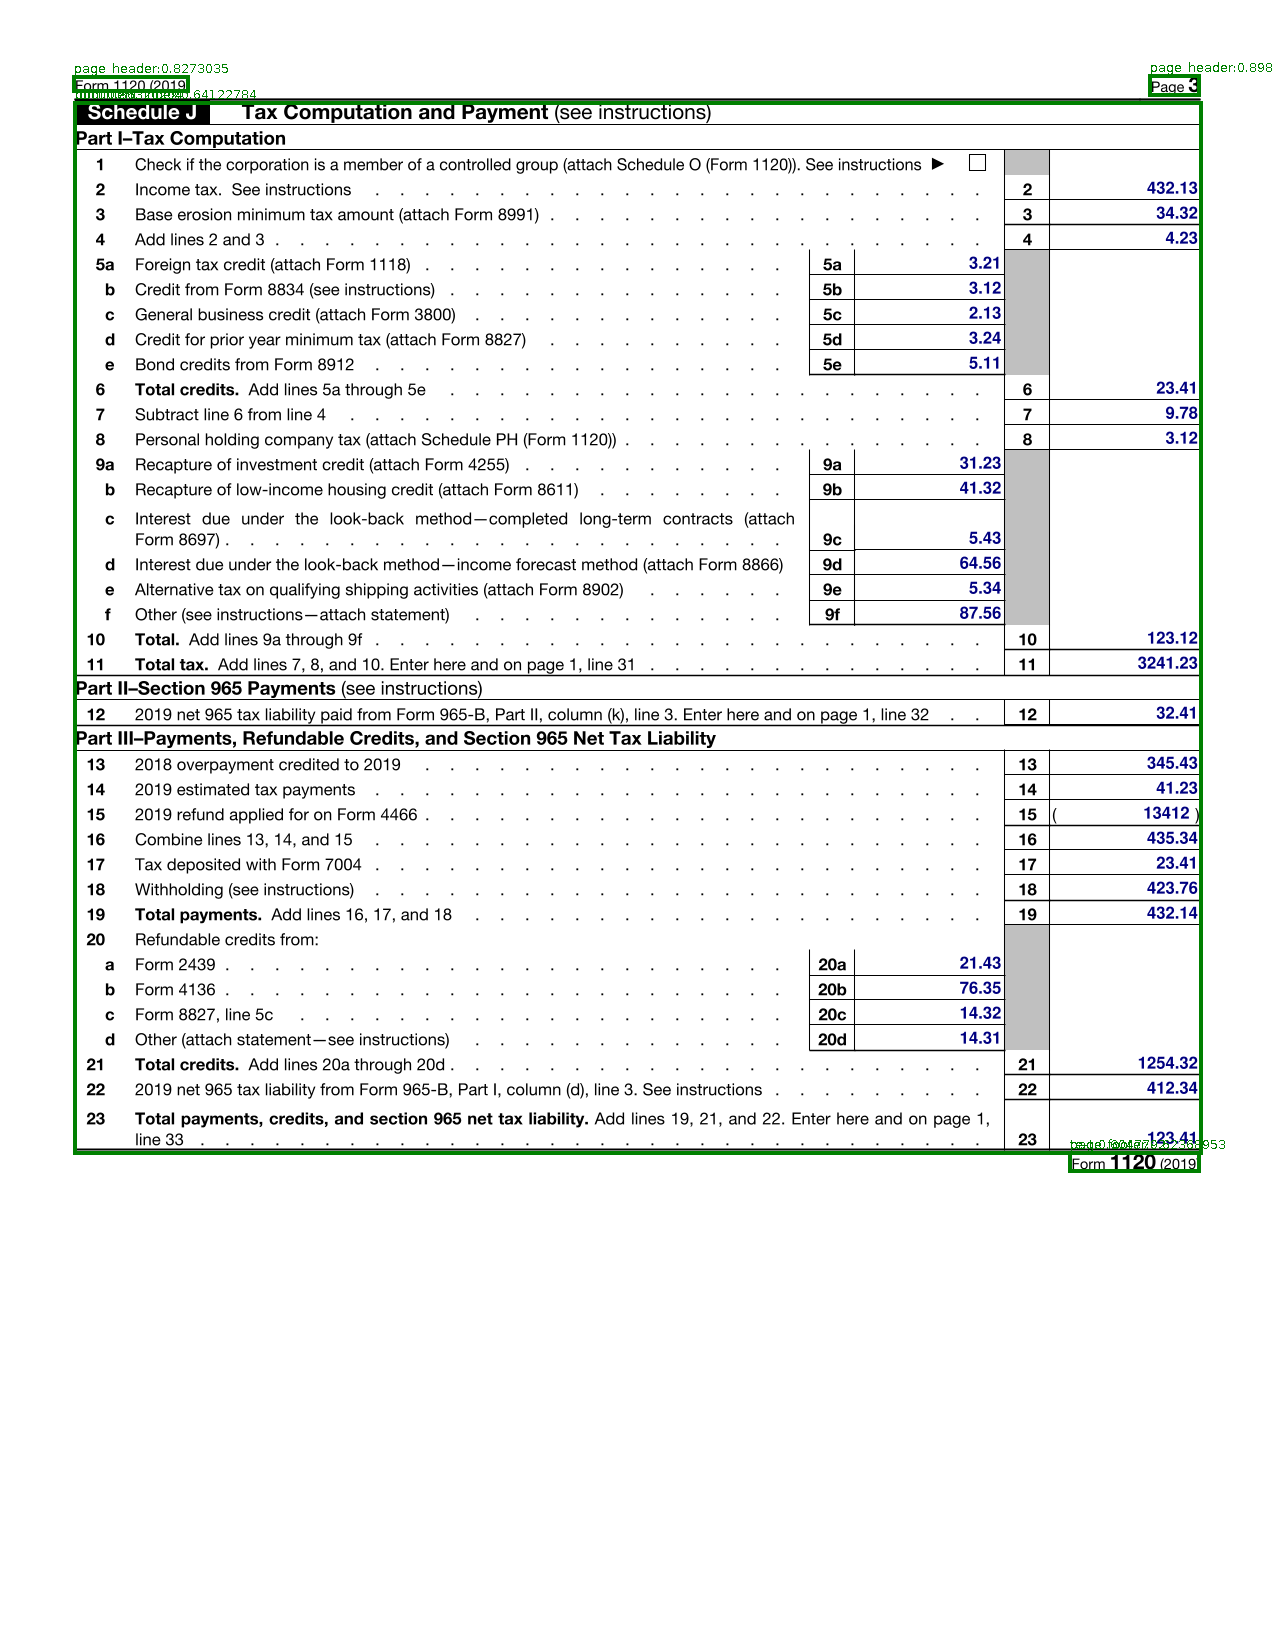


    Image #3:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/f1120.pdf
    Resolution: 150 dpi
    Width: 1274 px
    Height: 1649 px
    Mode: ImageType.TYPE_3BYTE_BGR
    Number of channels: 3


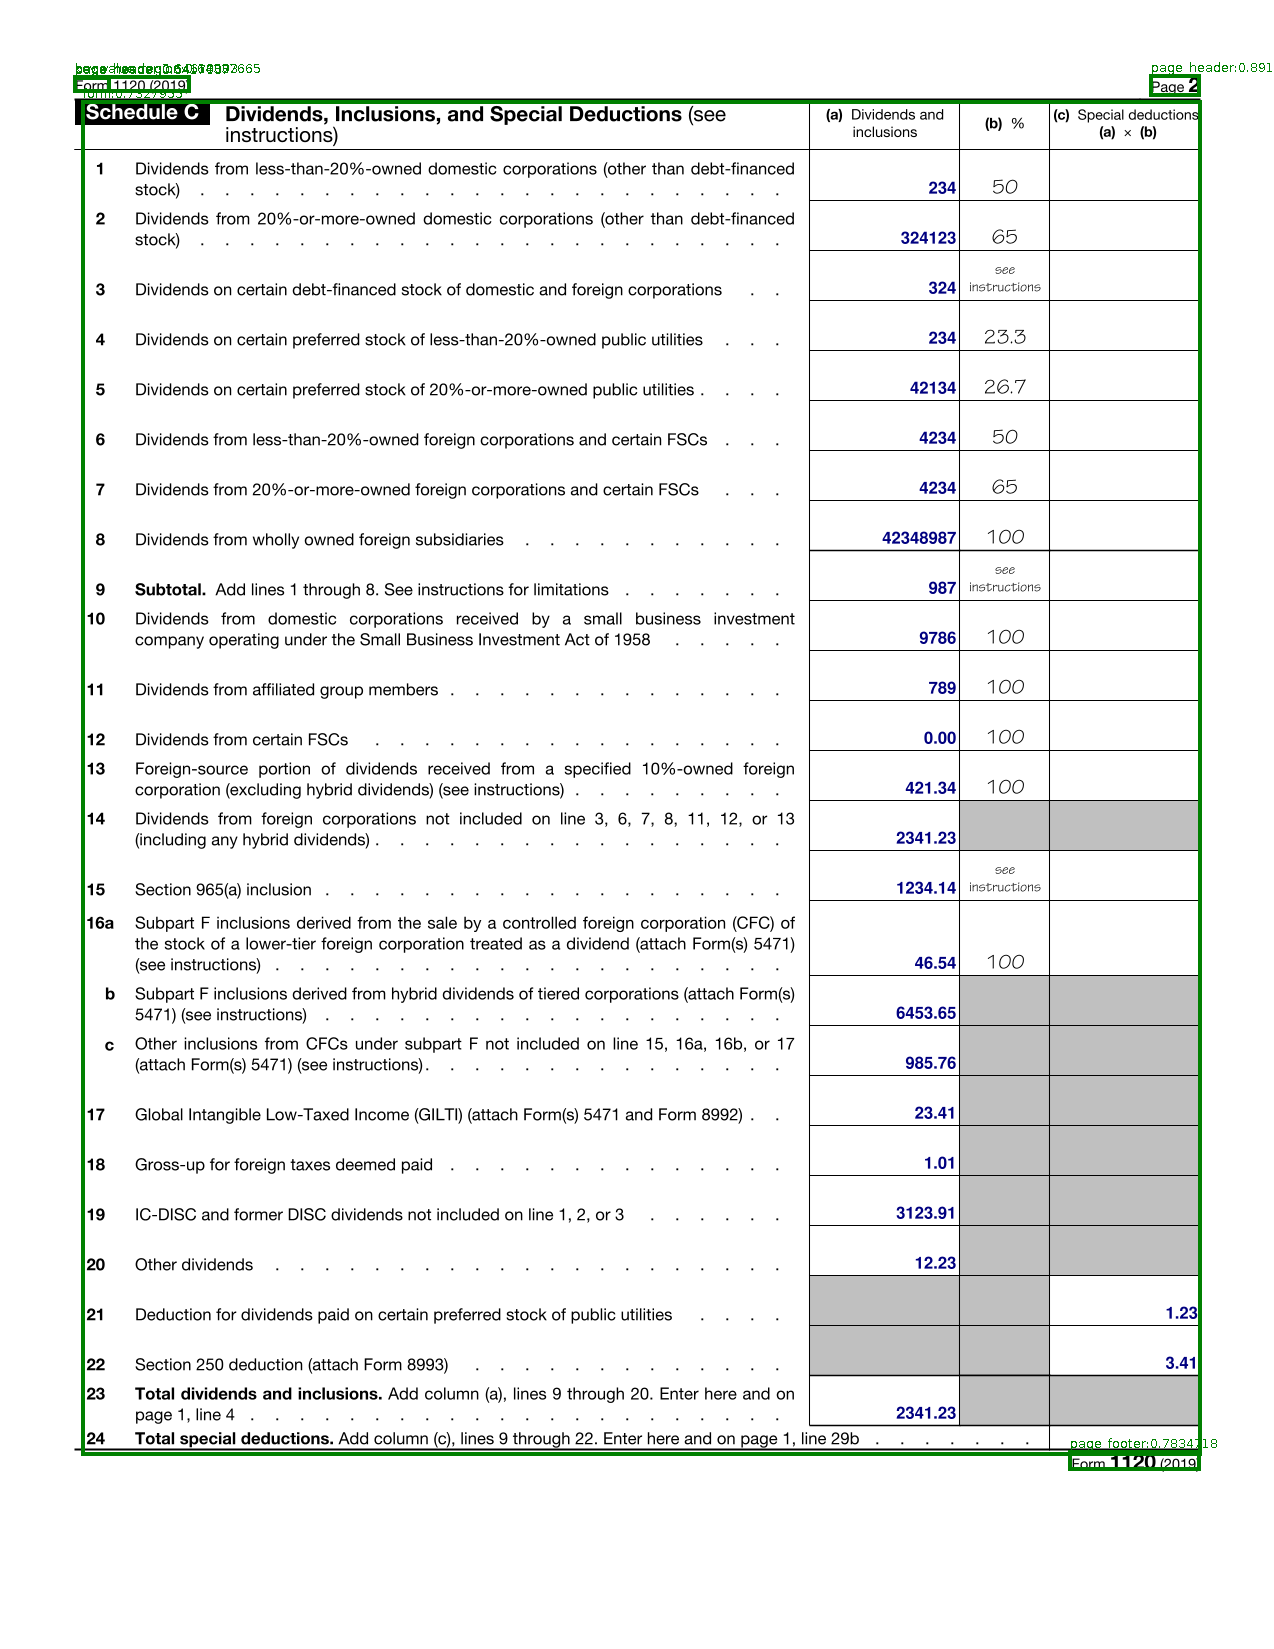


    Image #4:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/f1120.pdf
    Resolution: 150 dpi
    Width: 1274 px
    Height: 1649 px
    Mode: ImageType.TYPE_3BYTE_BGR
    Number of channels: 3


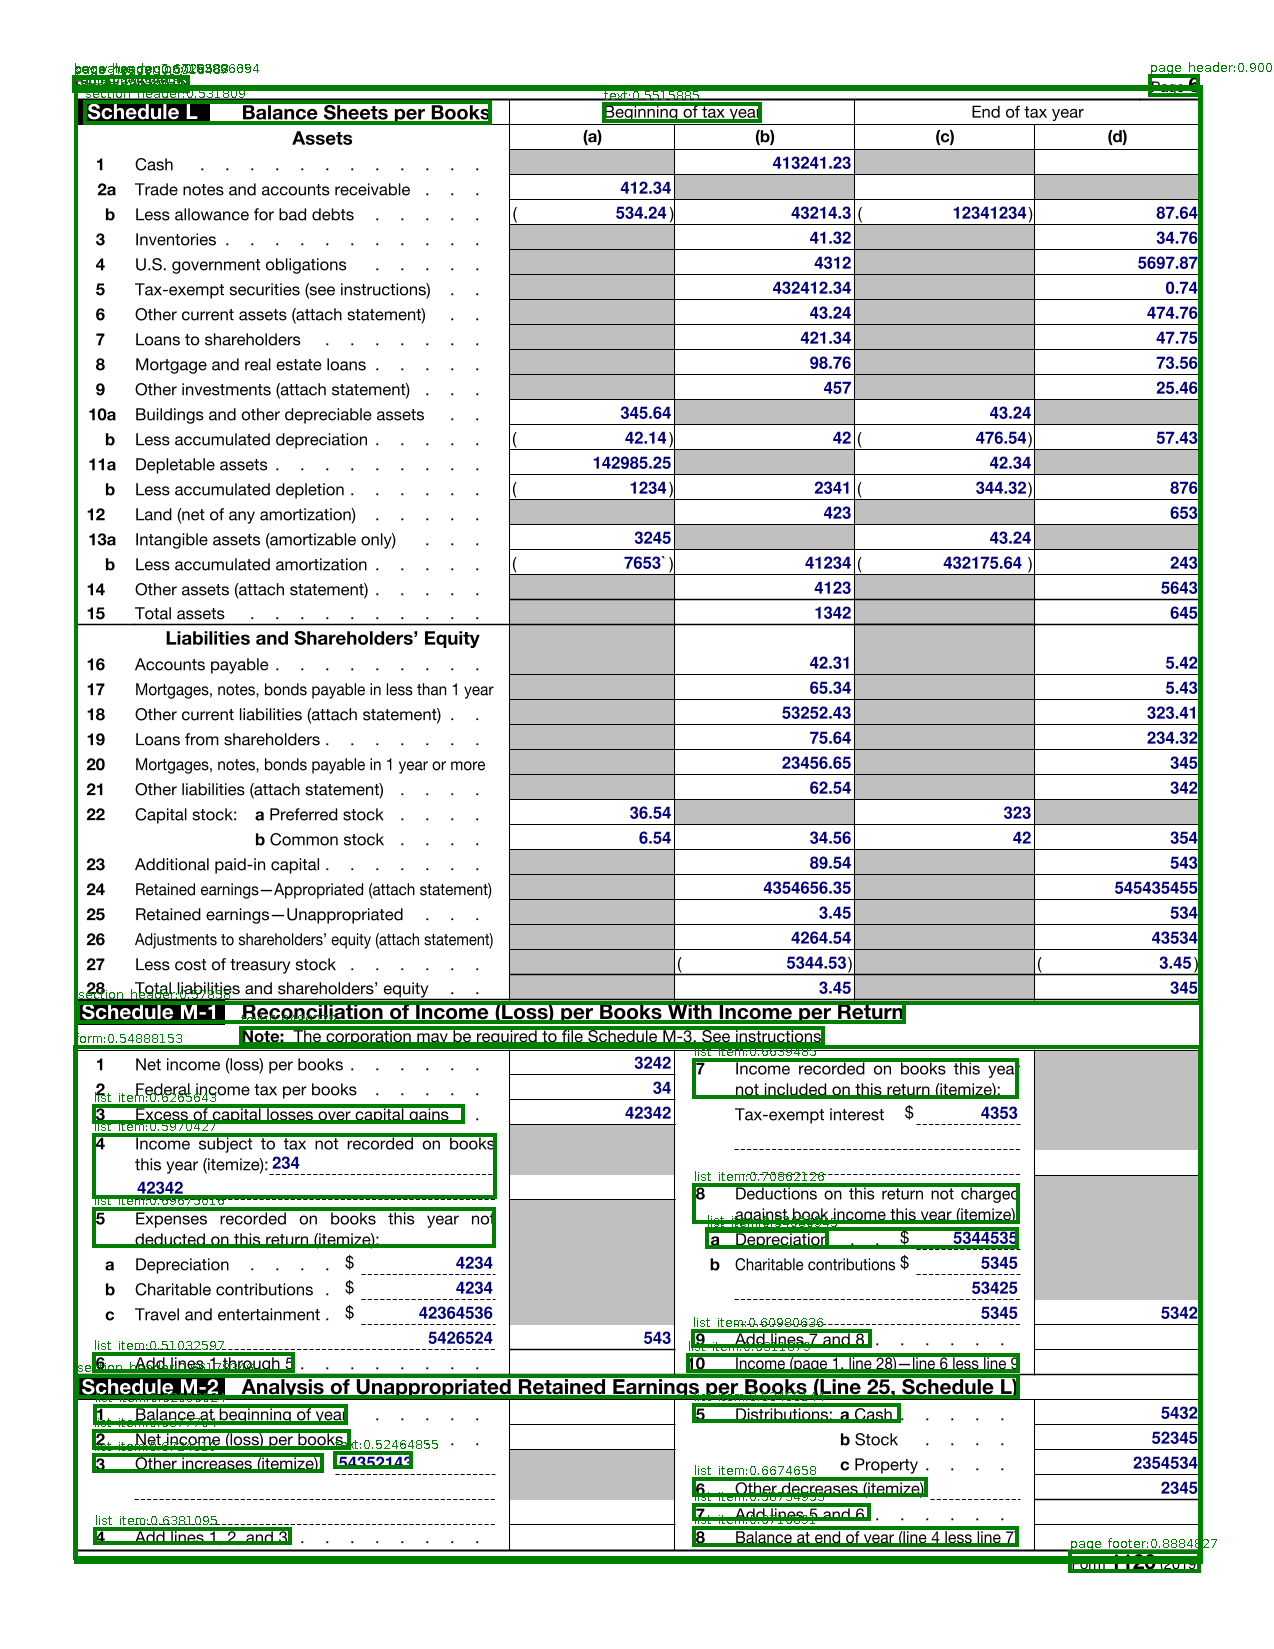


    Image #5:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/f1120.pdf
    Resolution: 150 dpi
    Width: 1274 px
    Height: 1649 px
    Mode: ImageType.TYPE_3BYTE_BGR
    Number of channels: 3


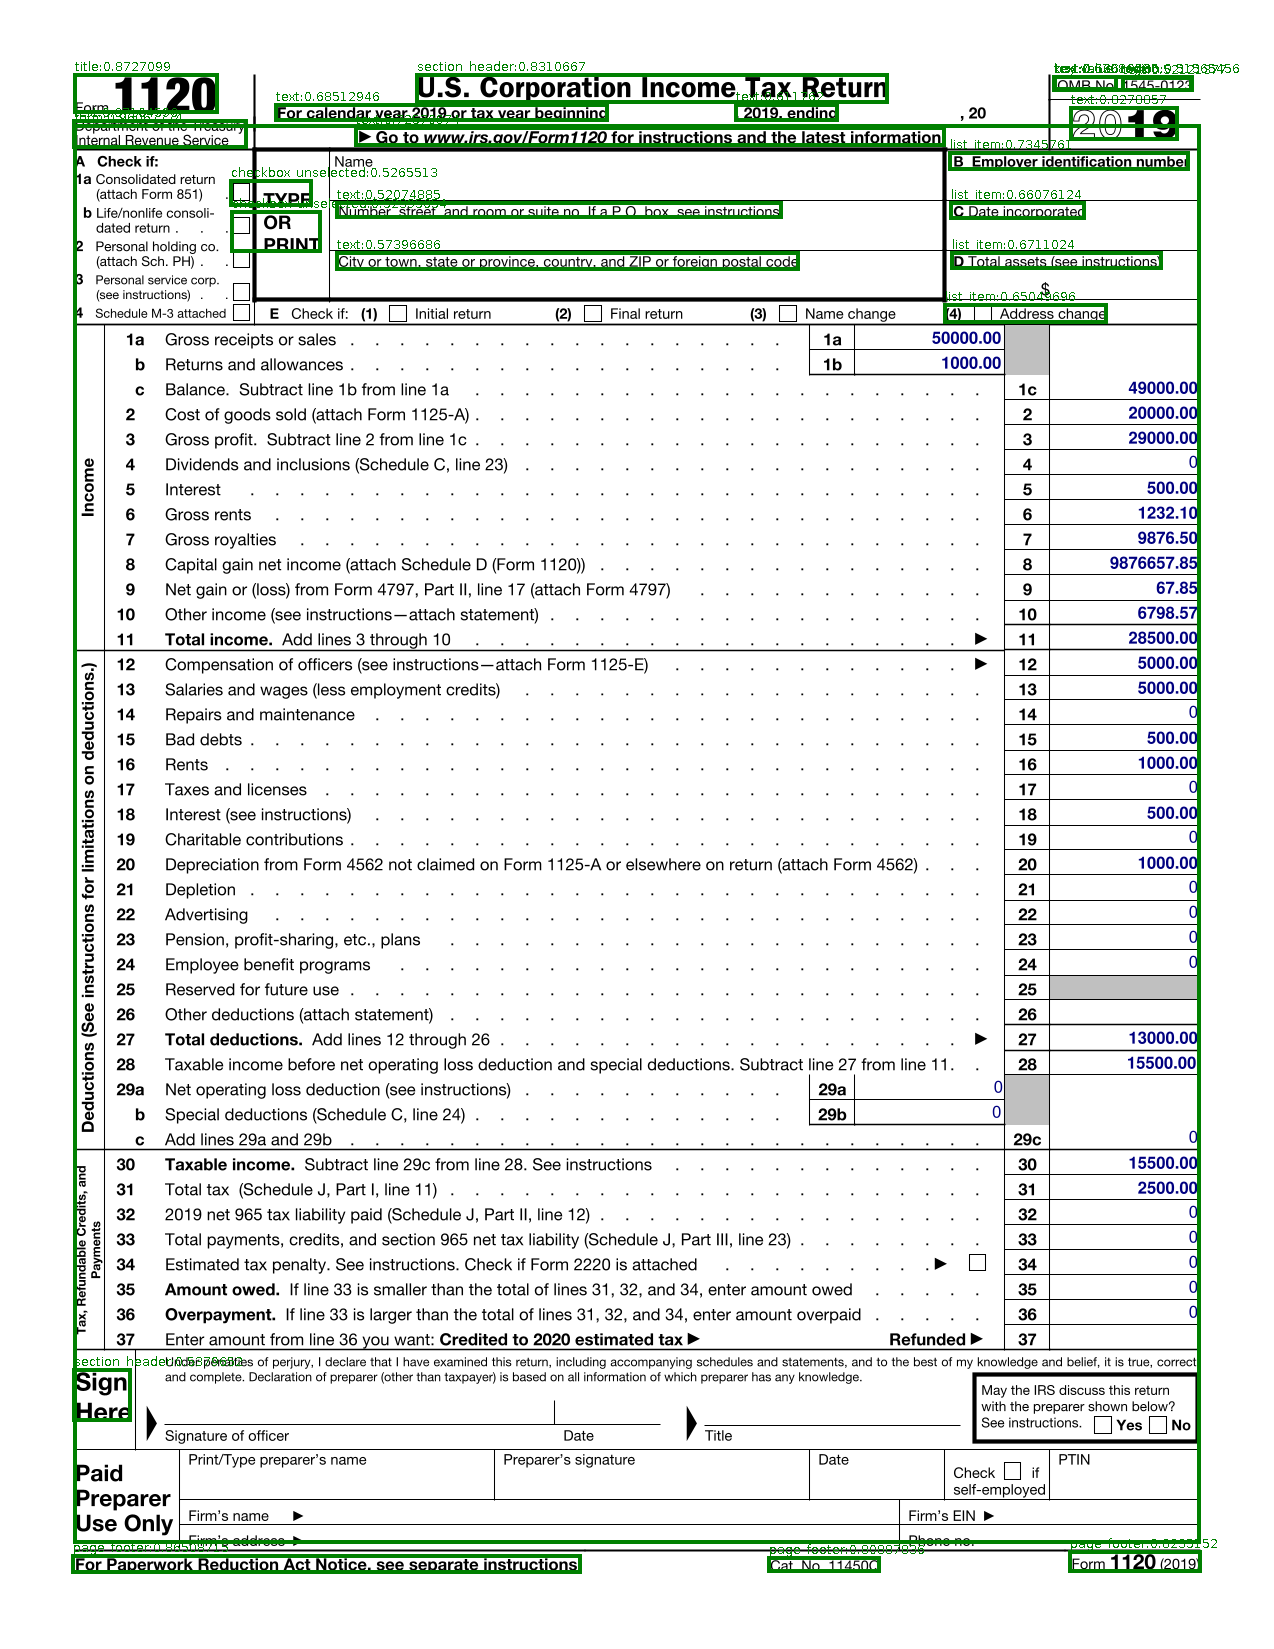

In [7]:
result = pipeline.transform(pdf_df).cache()
display_images(result, "image_with_regions", limit=10)

## Detected regions

In [8]:
regions = result \
    .select("path", "pagenum", f.explode("regions").alias("region")) \
    .select(f.element_at(f.split("path", "/"), -1).alias("file"), "pagenum", "region.*") \
    .select("file", "pagenum", "label", f.round("score", 3).alias("score"),
            f.round("x").alias("x"), f.round("y").alias("y"),
            f.round("width").alias("width"), f.round("height").alias("height"))

regions.show(50, truncate=False)

+---------+-------+-------------------+-----+------+------+------+------+
|file     |pagenum|label              |score|x     |y     |width |height|
+---------+-------+-------------------+-----+------+------+------+------+
|f1120.pdf|3      |list_item          |0.967|103.0 |365.0 |993.0 |59.0  |
|f1120.pdf|3      |table              |0.937|73.0  |577.0 |1128.0|196.0 |
|f1120.pdf|3      |table              |0.937|73.0  |849.0 |1128.0|200.0 |
|f1120.pdf|3      |page_footer        |0.936|1066.0|1528.0|133.0 |18.0  |
|f1120.pdf|3      |list_item          |0.933|103.0 |511.0 |992.0 |61.0  |
|f1120.pdf|3      |list_item          |0.926|103.0 |433.0 |992.0 |38.0  |
|f1120.pdf|3      |list_item          |0.924|95.0  |332.0 |232.0 |17.0  |
|f1120.pdf|3      |page_header        |0.922|1151.0|76.0  |49.0  |20.0  |
|f1120.pdf|3      |list_item          |0.902|94.0  |482.0 |384.0 |18.0  |
|f1120.pdf|3      |list_item          |0.897|95.0  |156.0 |296.0 |16.0  |
|f1120.pdf|3      |list_item          

In [9]:
regions.groupBy("label").agg(f.count("*").alias("count"), f.round(f.avg("score"), 3).alias("avg_score")) \
    .orderBy(f.desc("count")).show(truncate=False)

+-------------------+-----+---------+
|label              |count|avg_score|
+-------------------+-----+---------+
|list_item          |48   |0.732    |
|text               |17   |0.641    |
|page_header        |14   |0.727    |
|section_header     |9    |0.629    |
|form               |8    |0.765    |
|page_footer        |8    |0.786    |
|checkbox_unselected|5    |0.61     |
|key_value_region   |5    |0.618    |
|table              |3    |0.861    |
|checkbox_selected  |2    |0.691    |
|document_index     |2    |0.641    |
|title              |1    |0.873    |
+-------------------+-----+---------+



In [10]:
spark.stop()